# Quantum Gates — Interactive Companion Notebook

### Based on: QC_notes_gates.pdf — Chapter 3 (Quantum Gates) and selected parts of Chapter 4

This notebook is a hands-on, Qiskit-based companion to the lecture-note chapter on **Quantum Gates**. It follows the same structure and equation numbering as the PDF, so you can read the derivation and immediately see it verified in code.

Style and structure are inspired by:
- IBM Qiskit Community Tutorials (Coding With Qiskit, ep.4 — Gates)
- Qiskit Community Tutorials — Teach Me Quantum 2018 / Teach Me Qiskit 2018
- Qiskit/qiskit-tutorials (official GitHub tutorials)
- IBM Quantum Learning — Basics of Quantum Information course

Run the cells top to bottom. Each section starts with a short theory recap (with equation numbers from the notes) followed by Qiskit code that builds, visualizes and verifies the gate.

## References used to build this notebook

1. QC_notes_gates.pdf — Chapter 3 'Quantum Gates' and Chapter 4 excerpt (primary source)
2. Qiskit Community Tutorials — https://github.com/qiskit-community/qiskit-community-tutorials
3. Coding With Qiskit, Episode 4: Gates — .../Coding_With_Qiskit/ep4_Gates.ipynb
4. Teach Me Quantum 2018 — Basic Intro to QC — .../awards/teach_me_quantum_2018
5. Teach Me Qiskit 2018 — .../awards/teach_me_qiskit_2018
6. Qiskit/qiskit-tutorials — https://github.com/Qiskit/qiskit-tutorials
7. IBM Quantum Learning — https://quantum.cloud.ibm.com/learning/en
8. IBM Quantum Learning — Basics of Quantum Information course

Install requirements if needed:

    pip install qiskit qiskit-aer matplotlib numpy

In [1]:
pip install qiskit qiskit-aer matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 8.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 9.4 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [qiskit-aer]4 [qiskit-aer]
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator, DensityMatrix, state_fidelity
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector, plot_histogram
from qiskit.circuit.library import QFT, UnitaryGate
np.set_printoptions(precision=3, suppress=True)
print('Qiskit environment ready.')

Qiskit environment ready.


## 1. The General Single-Qubit Gate (Eq. 3.1 – 3.8)

A single qubit evolves under a unitary operator U = exp(-iHt/hbar). Writing the Hamiltonian as H = h0 + beta n.sigma (Eq. 3.3), the evolution operator becomes, up to a global phase exp(i alpha):

  U = exp(i alpha) Rn(eta),   Rn(eta) = exp(-i eta n.sigma / 2) = cos(eta/2) I - i sin(eta/2) n.sigma   (Eq. 3.6 – 3.8)

Rn(eta) rotates the Bloch-sphere vector anticlockwise by angle eta about axis n (Eq. 3.9 – 3.10). This is exactly what Qiskit's RX, RY, RZ and general U gates implement.

Below we build Rn(eta) directly from Eq. 3.8 and check it against Qiskit's RZ gate.

In [3]:
def Rn_matrix(n, eta):
    '''Builds Rn(eta) = cos(eta/2) I - i sin(eta/2) (n.sigma), directly from Eq. 3.8'''
    n = np.array(n) / np.linalg.norm(n)
    sx = np.array([[0, 1], [1, 0]])
    sy = np.array([[0, -1j], [1j, 0]])
    sz = np.array([[1, 0], [0, -1]])
    ndotsigma = n[0]*sx + n[1]*sy + n[2]*sz
    I = np.eye(2)
    return np.cos(eta/2)*I - 1j*np.sin(eta/2)*ndotsigma

def equal_up_to_phase(A, B, atol=1e-6):
    '''Check if two matrices are equal up to an overall complex phase.'''
    idx = np.unravel_index(np.argmax(np.abs(B)), B.shape)
    phase = A[idx] / B[idx]
    ok = np.allclose(A, phase * B, atol=atol)
    return ok, phase

eta0 = 0.7
n_axis = [0, 0, 1]
qc_rz_test = QuantumCircuit(1)
qc_rz_test.rz(eta0, 0)
U_qiskit = Operator(qc_rz_test).data
U_notes = Rn_matrix(n_axis, eta0)

print('Rz(eta) from Qiskit:')
print(U_qiskit)
print('Rn(eta) from Eq. 3.8 with n = z:')
print(U_notes)
print('Match:', np.allclose(U_qiskit, U_notes))

Rz(eta) from Qiskit:
[[0.939-0.343j 0.   +0.j   ]
 [0.   +0.j    0.939+0.343j]]
Rn(eta) from Eq. 3.8 with n = z:
[[0.939-0.343j 0.   +0.j   ]
 [0.   +0.j    0.939+0.343j]]
Match: True


## 1.1 Rn(eta) <=> Rotation of the Bloch Vector (Eq. 3.9 – 3.21)

Section 3.1.1 proves that Rn(eta) acting on |m> produces |m'>, the vector m rotated anticlockwise about n by eta. Two special cases are proven explicitly:

- Rz(eta)|theta,phi> = |theta, phi+eta>   (Eq. 3.13 – 3.15): rotation about z changes only the azimuthal angle phi.
- Rx(eta)|theta,pi/2> = |theta-eta, pi/2>  (Eq. 3.19 – 3.21): rotation about x, for a state in the y-z plane, changes only the polar angle theta.

Let's watch this happen on the Bloch sphere.

Initial state |theta, phi>:


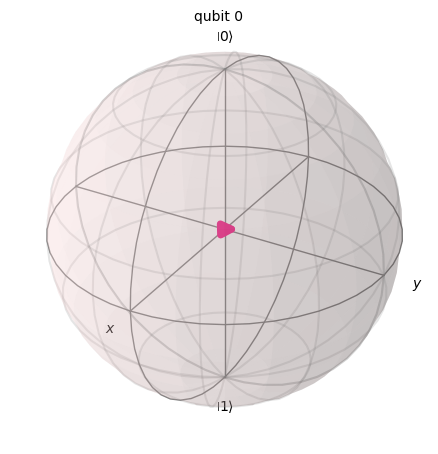

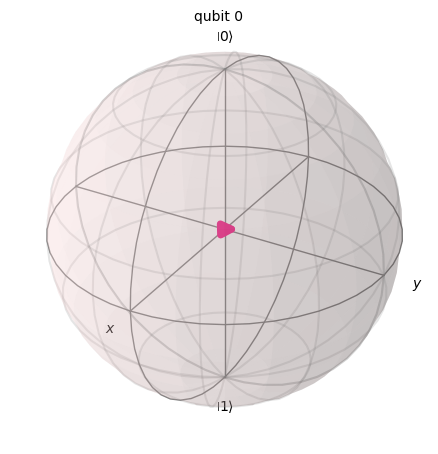

In [4]:
theta, phi, eta = np.pi/3, np.pi/5, np.pi/2

qc_in = QuantumCircuit(1)
qc_in.ry(theta, 0)
qc_in.rz(phi, 0)
psi_in = Statevector(qc_in)
print('Initial state |theta, phi>:')
plot_bloch_multivector(psi_in)

After Rz(eta): expect |theta, phi + eta>


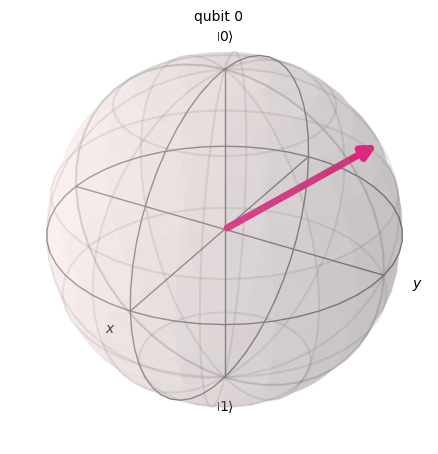

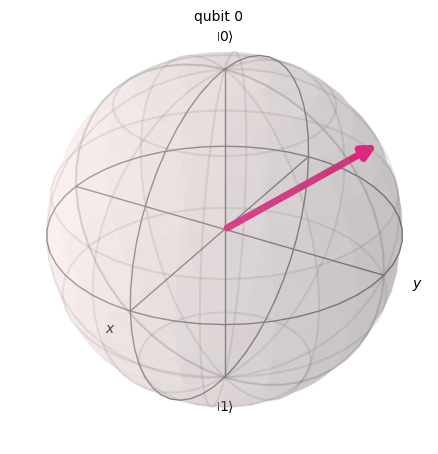

In [5]:
qc_out = qc_in.copy()
qc_out.rz(eta, 0)
psi_out = Statevector(qc_out)
print('After Rz(eta): expect |theta, phi + eta>')
plot_bloch_multivector(psi_out)

In [6]:
def bloch_angles(sv):
    rho = DensityMatrix(sv).data
    x = 2*np.real(rho[0, 1])
    y = 2*np.imag(rho[1, 0])
    z = np.real(rho[0, 0] - rho[1, 1])
    theta_ = np.arccos(np.clip(z, -1, 1))
    phi_ = np.arctan2(y, x)
    return theta_, phi_

th_in, ph_in = bloch_angles(psi_in)
th_out, ph_out = bloch_angles(psi_out)
print(f'theta: {th_in:.3f} -> {th_out:.3f}  (should be unchanged)')
print(f'phi:   {ph_in:.3f} -> {ph_out:.3f}  (expected {(ph_in+eta):.3f} mod 2pi)')

theta: 1.047 -> 1.047  (should be unchanged)
phi:   0.628 -> 2.199  (expected 2.199 mod 2pi)


Now the Rx(eta) case: prepare a state in the y-z plane (phi = pi/2) and rotate about x. Theory (Eq. 3.19) predicts theta -> theta - eta while phi stays at pi/2.

In [7]:
theta2, eta2 = 2*np.pi/5, np.pi/4
qc_in2 = QuantumCircuit(1)
qc_in2.ry(theta2, 0)
qc_in2.rz(np.pi/2, 0)
psi_in2 = Statevector(qc_in2)

qc_out2 = qc_in2.copy()
qc_out2.rx(eta2, 0)
psi_out2 = Statevector(qc_out2)

th_in2, ph_in2 = bloch_angles(psi_in2)
th_out2, ph_out2 = bloch_angles(psi_out2)
print(f'theta: {th_in2:.3f} -> {th_out2:.3f}  (expected {(th_in2-eta2):.3f})')
print(f'phi:   {ph_in2:.3f} -> {ph_out2:.3f}  (should stay pi/2 = {np.pi/2:.3f})')

theta: 1.257 -> 0.471  (expected 0.471)
phi:   1.571 -> 1.571  (should stay pi/2 = 1.571)


## 2. The Elementary Single-Qubit Gates (Sec. 3.1.2)

For every gate below we show: the circuit symbol, its matrix (compare with the notes' equation numbers), and its action on the computational basis states |0>, |1>. A small helper function does the repetitive work.

In [8]:
def gate_report(name, build_fn, eq_ref=''):
    qc = QuantumCircuit(1)
    build_fn(qc)
    print(f'=== {name} {eq_ref} ===')
    print(qc.draw(output='text'))
    U = Operator(qc).data
    print('Matrix:')
    print(np.round(U, 3))
    for label in ['0', '1']:
        out = Statevector.from_label(label).evolve(qc)
        print(f'{name}|{label}> = {out.data.round(3)}')
    print()
    return qc

### 2.1 X gate (NOT gate) — Eq. 3.28 – 3.31

X|0> = |1>,  X|1> = |0>.  Also X = i*exp(-i pi X/2) (Eq. 3.31): a pi-rotation about the x-axis (up to phase).

=== X (Eq. 3.28) ===
   ┌───┐
q: ┤ X ├
   └───┘
Matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X|0> = [0.+0.j 1.+0.j]
X|1> = [1.+0.j 0.+0.j]



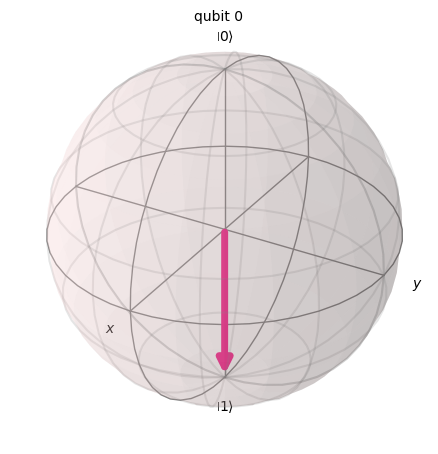

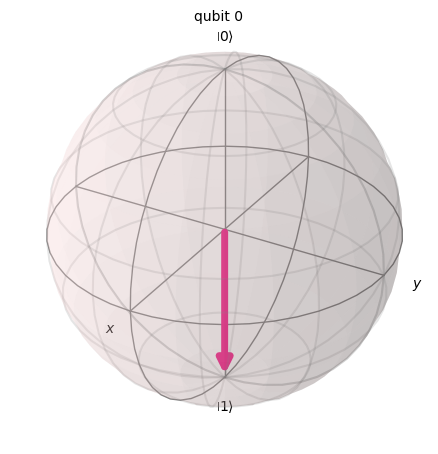

In [9]:
qc_x = gate_report('X', lambda qc: qc.x(0), '(Eq. 3.28)')
plot_bloch_multivector(Statevector.from_label('0').evolve(qc_x))

### 2.2 Y gate — Eq. 3.32 – 3.35

Y|0> = i|1>,  Y|1> = -i|0>.

In [10]:
qc_y = gate_report('Y', lambda qc: qc.y(0), '(Eq. 3.32)')

=== Y (Eq. 3.32) ===
   ┌───┐
q: ┤ Y ├
   └───┘
Matrix:
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Y|0> = [0.+0.j 0.+1.j]
Y|1> = [0.-1.j 0.+0.j]



### 2.3 Z gate — Eq. 3.36 – 3.39

Z|0> = |0>,  Z|1> = -|1>. A pi phase-flip; a pi-rotation about z.

In [11]:
qc_z = gate_report('Z', lambda qc: qc.z(0), '(Eq. 3.36)')

=== Z (Eq. 3.36) ===
   ┌───┐
q: ┤ Z ├
   └───┘
Matrix:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Z|0> = [1.+0.j 0.+0.j]
Z|1> = [ 0.+0.j -1.+0.j]



### 2.4 T (pi/8) gate — Eq. 3.40 – 3.43

T|0> = |0>,  T|1> = exp(i pi/4)|1>. Called the 'pi/8 gate' because, up to a global phase exp(i pi/8), it equals diag(exp(-i pi/8), exp(i pi/8)) = exp(-i pi Z/8).

In [12]:
qc_t = gate_report('T', lambda qc: qc.t(0), '(Eq. 3.40)')

Z = np.array([[1, 0], [0, -1]])
T_formula = np.exp(1j*np.pi/8) * (np.cos(np.pi/8)*np.eye(2) - 1j*np.sin(np.pi/8)*Z)
print('T from Eq. 3.43:')
print(np.round(T_formula, 3))
print('Matches Qiskit T gate:', np.allclose(Operator(qc_t).data, T_formula))

=== T (Eq. 3.40) ===
   ┌───┐
q: ┤ T ├
   └───┘
Matrix:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
T|0> = [1.+0.j 0.+0.j]
T|1> = [0.   +0.j    0.707+0.707j]

T from Eq. 3.43:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
Matches Qiskit T gate: True


### 2.5 S gate — Eq. 3.44 – 3.48

S|0> = |0>,  S|1> = i|1>.  Note S = T^2 (Eq. 3.48).

In [13]:
qc_s = gate_report('S', lambda qc: qc.s(0), '(Eq. 3.44)')

qc_t2 = QuantumCircuit(1)
qc_t2.t(0)
qc_t2.t(0)
print('T^2 == S ?', np.allclose(Operator(qc_t2).data, Operator(qc_s).data))

=== S (Eq. 3.44) ===
   ┌───┐
q: ┤ S ├
   └───┘
Matrix:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
S|0> = [1.+0.j 0.+0.j]
S|1> = [0.+0.j 0.+1.j]

T^2 == S ? True


### 2.6 Hadamard gate — Eq. 3.49 – 3.55

H|0> = (|0>+|1>)/sqrt(2),  H|1> = (|0>-|1>)/sqrt(2). In Pauli-matrix form: H = (X+Z)/sqrt(2) (Eq. 3.52) — i.e. H = n.sigma with n = (ex+ez)/sqrt(2), a pi-rotation about the axis halfway between x and z.

=== H (Eq. 3.49) ===
   ┌───┐
q: ┤ H ├
   └───┘
Matrix:
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
H|0> = [0.707+0.j 0.707+0.j]
H|1> = [ 0.707+0.j -0.707+0.j]

H = (X+Z)/sqrt(2)  (Eq. 3.52):
[[ 0.707  0.707]
 [ 0.707 -0.707]]
Matches Qiskit H gate: True


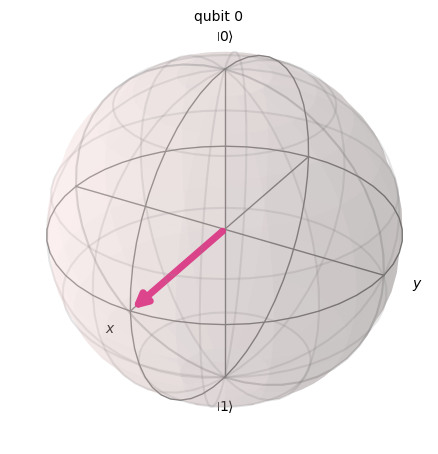

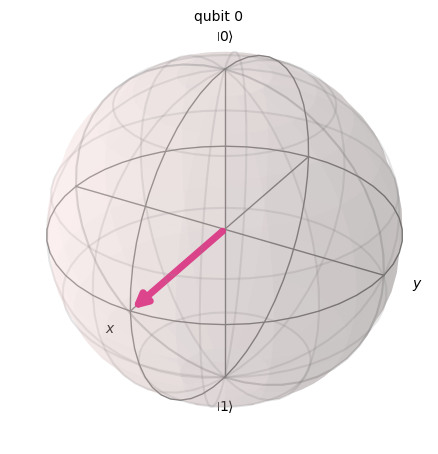

In [14]:
qc_h = gate_report('H', lambda qc: qc.h(0), '(Eq. 3.49)')

X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])
H_formula = (X + Z) / np.sqrt(2)
print('H = (X+Z)/sqrt(2)  (Eq. 3.52):')
print(np.round(H_formula, 3))
print('Matches Qiskit H gate:', np.allclose(Operator(qc_h).data, H_formula))

plot_bloch_multivector(Statevector.from_label('0').evolve(qc_h))

## 3. Single-Qubit Universal Gates: H and T (Sec. 3.1.3)

The notes prove that repeated application of H and T can approximate ANY single-qubit unitary to arbitrary accuracy, because:

  H T H = exp(i pi/8) (cos(pi/8) I - i sin(pi/8) X)   (Eq. 3.56)

  T H T H = Rp(eta), with cos(eta/2) = cos^2(pi/8)   (Eq. 3.60 – 3.71)

and eta/pi is irrational, so repeated applications of Rp(eta) never exactly repeat and densely fill all rotation angles about the fixed axis p. Combined with Rq(eta) = H Rp(eta) H (Eq. 3.76) about a second axis q, ANY rotation Rn(theta) can be built (Eq. 3.77 – 3.80).

Let's verify Eq. 3.56 and 3.60-3.71 numerically.

In [15]:
qc_hth = QuantumCircuit(1)
qc_hth.h(0)
qc_hth.t(0)
qc_hth.h(0)
HTH = Operator(qc_hth).data
print('Circuit implementing H, then T, then H (matrix = H.T.H):')
print(qc_hth.draw(output='text'))
print('Matrix of H.T.H:')
print(np.round(HTH, 3))

formula = np.exp(1j*np.pi/8) * (np.cos(np.pi/8)*np.eye(2) - 1j*np.sin(np.pi/8)*X)
print('Formula from Eq. 3.56:')
print(np.round(formula, 3))
print('Exact match:', np.allclose(HTH, formula))

Circuit implementing H, then T, then H (matrix = H.T.H):
   ┌───┐┌───┐┌───┐
q: ┤ H ├┤ T ├┤ H ├
   └───┘└───┘└───┘
Matrix of H.T.H:
[[0.854+0.354j 0.146-0.354j]
 [0.146-0.354j 0.854+0.354j]]
Formula from Eq. 3.56:
[[0.854+0.354j 0.146-0.354j]
 [0.146-0.354j 0.854+0.354j]]
Exact match: True


In [16]:
qc_thth = QuantumCircuit(1)
qc_thth.h(0)
qc_thth.t(0)
qc_thth.h(0)
qc_thth.t(0)
THTH = Operator(qc_thth).data
print('Matrix of T.H.T.H:')
print(np.round(THTH, 3))

eta_p = 2*np.arccos(np.cos(np.pi/8)**2)
print('eta (Eq. 3.71) =', eta_p, ' ; eta/pi =', eta_p/np.pi, ' (irrational -> gate never exactly repeats)')

p_axis = np.array([np.cos(np.pi/8), np.sin(np.pi/8), np.cos(np.pi/8)])
Rp_eta = Rn_matrix(p_axis, eta_p)
print('Rp(eta) from Eq. 3.65 & 3.68:')
print(np.round(Rp_eta, 3))

ok, phase = equal_up_to_phase(THTH, Rp_eta)
print('T.H.T.H equals Rp(eta) up to global phase?', ok)
print('measured phase =', phase, '  expected phase exp(i pi/4) =', np.exp(1j*np.pi/4))

Matrix of T.H.T.H:
[[0.854+0.354j 0.146-0.354j]
 [0.354-0.146j 0.354+0.854j]]
eta (Eq. 3.71) = 1.0960568152406256  ; eta/pi = 0.34888572011021163  (irrational -> gate never exactly repeats)
Rp(eta) from Eq. 3.65 & 3.68:
[[ 0.854-0.354j -0.146-0.354j]
 [ 0.146-0.354j  0.854+0.354j]]
T.H.T.H equals Rp(eta) up to global phase? True
measured phase = (0.7071067811865472+0.7071067811865474j)   expected phase exp(i pi/4) = (0.7071067811865476+0.7071067811865475j)


To see this universality used in practice, Qiskit provides a **Solovay-Kitaev** decomposition that approximates an arbitrary single-qubit gate using only Clifford+T gates (H, T, T-dagger, S, X, Y, Z) — exactly the gate set discussed above.

In [17]:
try:
    try:
        from qiskit.synthesis import SolovayKitaevDecomposition
    except ImportError:
        from qiskit.transpiler.passes.synthesis import SolovayKitaevDecomposition
    target = QuantumCircuit(1)
    target.rz(0.9, 0)
    skd = SolovayKitaevDecomposition()
    approx = skd(target)
    print('Approximated circuit (H/T/S/X/Y/Z only):')
    print(approx.draw(output='text'))
    err = np.linalg.norm(Operator(approx).data - Operator(target).data)
    print('Approximation error (operator norm):', err)
except Exception as e:
    print('Solovay-Kitaev synthesis not available in this Qiskit installation:', e)
    print('This is an optional demo of Sec. 3.1.3 universality in practice.')

Solovay-Kitaev synthesis not available in this Qiskit installation: 'SolovayKitaevDecomposition' object is not callable
This is an optional demo of Sec. 3.1.3 universality in practice.


## 4. Multi-Qubit States and Controlled Gates (Sec. 3.1.4)

A controlled-U gate acts as:

  CU |a,b> = U2^a |a,b>   (Eq. 3.81)

i.e. U is applied to the target (second) qubit only when the control (first) qubit is |1>. Let's build a GENERAL controlled-U gate from an arbitrary single-qubit unitary and check it against Eq. 3.81.

In [18]:
U = Operator(qc_h).data
cU = UnitaryGate(U, label='U').control(1)

qc_cu = QuantumCircuit(2)
qc_cu.append(cU, [0, 1])
print(qc_cu.draw(output='text'))

for a in ['0', '1']:
    for b in ['0', '1']:
        label = a + b
        out = Statevector.from_label(label).evolve(qc_cu)
        print(f'CU|{a},{b}> = {out.data.round(3)}')

          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ U ├
     └───┘
CU|0,0> = [1.+0.j 0.-0.j 0.+0.j 0.-0.j]
CU|0,1> = [-0.   -0.j  0.707+0.j -0.   -0.j  0.707+0.j]
CU|1,0> = [-0.+0.j  0.-0.j  1.-0.j  0.-0.j]
CU|1,1> = [-0.   -0.j  0.707-0.j  0.   -0.j -0.707+0.j]


### 4.1 CNOT / Controlled-X gate — Eq. 3.82

CX|a,b> = |a, b XOR a>. This is the quantum analogue of classical XOR-with-control and, together with single-qubit gates, forms a universal gate set for quantum computing.

In [19]:
qc_cx = QuantumCircuit(2)
qc_cx.cx(0, 1)
print(qc_cx.draw(output='text'))
print('Truth table  CX|a,b> = |a, a xor b>  (control=qubit0=a, target=qubit1=b):')
for a in [0, 1]:
    for b in [0, 1]:
        sv = Statevector.from_label(f'{b}{a}')
        out = sv.evolve(qc_cx)
        idx = np.argmax(np.abs(out.data))
        outcome = format(idx, '02b')
        expected = f'{a^b}{a}'
        print(f'a={a}, b={b}  ->  measured (q1,q0)={outcome}   expected (q1,q0)={expected}')

          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘
Truth table  CX|a,b> = |a, a xor b>  (control=qubit0=a, target=qubit1=b):
a=0, b=0  ->  measured (q1,q0)=00   expected (q1,q0)=00
a=0, b=1  ->  measured (q1,q0)=10   expected (q1,q0)=10
a=1, b=0  ->  measured (q1,q0)=11   expected (q1,q0)=11
a=1, b=1  ->  measured (q1,q0)=01   expected (q1,q0)=01


### 4.2 SWAP gate — Eq. 3.83 – 3.85, Fig. 3.10

SWAP exchanges the states of two qubits. As shown in the notes, it can be built from three CNOTs.

In [20]:
qc_swap_manual = QuantumCircuit(2)
qc_swap_manual.cx(0, 1)
qc_swap_manual.cx(1, 0)
qc_swap_manual.cx(0, 1)

qc_swap_builtin = QuantumCircuit(2)
qc_swap_builtin.swap(0, 1)

print(qc_swap_manual.draw(output='text'))
print('3-CNOT circuit == built-in SWAP ?', np.allclose(Operator(qc_swap_manual).data, Operator(qc_swap_builtin).data))

sv = Statevector.from_label('01')
print('Input |q1 q0> = |01>  ->  after SWAP:', sv.evolve(qc_swap_manual))

          ┌───┐     
q_0: ──■──┤ X ├──■──
     ┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├──■──┤ X ├
     └───┘     └───┘
3-CNOT circuit == built-in SWAP ? True
Input |q1 q0> = |01>  ->  after SWAP: Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


### 4.3 Control-by-|0> vs Control-by-|1> — Fig. 3.11

A gate that triggers when the control is |0> (open circle) is related to a normal |1>-controlled gate by surrounding it with X gates on the control line.

In [21]:
qc_open_ctrl = QuantumCircuit(2)
qc_open_ctrl.cx(0, 1, ctrl_state=0)

qc_via_X = QuantumCircuit(2)
qc_via_X.x(0)
qc_via_X.cx(0, 1)
qc_via_X.x(0)

print('Open-control CX == X-CX-X ?', np.allclose(Operator(qc_open_ctrl).data, Operator(qc_via_X).data))
print(qc_open_ctrl.draw(output='text'))

Open-control CX == X-CX-X ? True
          
q_0: ──o──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘


## 5. n-Control Qubit Gates (Sec. 3.1.5)

### 5.1 Toffoli gate (CCX) — Fig. 3.12 – 3.13

C2_X |a,b,c> = |a, b, c XOR (a AND b)>. The target flips only when BOTH controls are |1>.

In [22]:
qc_ccx = QuantumCircuit(3)
qc_ccx.ccx(0, 1, 2)
print(qc_ccx.draw(output='text'))
print('Truth table for Toffoli (controls a,b ; target c):')
for a in [0, 1]:
    for b in [0, 1]:
        for c in [0, 1]:
            label = f'{c}{b}{a}'
            out = Statevector.from_label(label).evolve(qc_ccx)
            idx = np.argmax(np.abs(out.data))
            outbits = format(idx, '03b')
            print(f'a={a} b={b} c={c}  ->  c_out={outbits[0]}  (expect {c^(a&b)})')

          
q_0: ──■──
       │  
q_1: ──■──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘
Truth table for Toffoli (controls a,b ; target c):
a=0 b=0 c=0  ->  c_out=0  (expect 0)
a=0 b=0 c=1  ->  c_out=1  (expect 1)
a=0 b=1 c=0  ->  c_out=0  (expect 0)
a=0 b=1 c=1  ->  c_out=1  (expect 1)
a=1 b=0 c=0  ->  c_out=0  (expect 0)
a=1 b=0 c=1  ->  c_out=1  (expect 1)
a=1 b=1 c=0  ->  c_out=1  (expect 1)
a=1 b=1 c=1  ->  c_out=0  (expect 0)


### 5.2 Multi-Controlled-X (Cn gate) — Fig. 3.15

Any Cn_U gate can be decomposed into single-qubit-controlled gates (the notes prove this using repeated use of Eq. 3.27). Qiskit's MCXGate implements this directly.

In [23]:
from qiskit.circuit.library import MCXGate
n_controls = 4
mcx = MCXGate(n_controls)
qc_mcx = QuantumCircuit(n_controls + 1)
qc_mcx.append(mcx, range(n_controls + 1))
print(f'{n_controls}-controlled-X circuit (target flips only if ALL controls are |1>):')
print(qc_mcx.draw(output='text', fold=120))

all_ones = '1' * n_controls
sv_in = Statevector.from_label('0' + all_ones)
sv_out = sv_in.evolve(qc_mcx)
print('All controls = 1 -> target flips:', sv_out)

4-controlled-X circuit (target flips only if ALL controls are |1>):
          
q_0: ──■──
       │  
q_1: ──■──
       │  
q_2: ──■──
       │  
q_3: ──■──
     ┌─┴─┐
q_4: ┤ X ├
     └───┘
All controls = 1 -> target flips: Statevector([ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
             -0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
              0.+0.j, -0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
              0.+0.j,  0.+0.j,  0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
              0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j],
            dims=(2, 2, 2, 2, 2))


## 6. The Controlled-Phase Gate (Sec. 3.1.7)

A phase factor exp(i alpha) multiplying an output state can be safely ignored for single-qubit gates, but NOT inside a controlled gate: the phase should appear only when the control qubit is |1> (Eq. 3.100). This 'controlled-phase' can be implemented with an Rz(alpha) on the control line (Eq. 3.173, Fig. 3.18), or, for two qubits together, with the CP gate.

This is exactly the phase-kickback trick used throughout quantum algorithms (QPE, Shor, Grover).

In [24]:
alpha = np.pi / 3
qc_cp = QuantumCircuit(2)
qc_cp.h(0)
qc_cp.x(1)
qc_cp.cp(alpha, 0, 1)
print(qc_cp.draw(output='text'))

sv = Statevector(qc_cp)
amp_q0_0 = sv.data[2]
amp_q0_1 = sv.data[3]
measured_phase = np.angle(amp_q0_1) - np.angle(amp_q0_0)
print('Measured relative phase between q0=0 and q0=1 components:', measured_phase)
print('Expected (Eq. 3.100 with a=1):', alpha)

     ┌───┐         
q_0: ┤ H ├─■───────
     ├───┤ │P(π/3) 
q_1: ┤ X ├─■───────
     └───┘         
Measured relative phase between q0=0 and q0=1 components: 1.0471975511965976
Expected (Eq. 3.100 with a=1): 1.0471975511965976


## 7. The No-Cloning Theorem (Sec. 3.2)

No unitary can copy an arbitrary unknown state: if U|psi>|s> = |psi>|psi> and U|phi>|s> = |phi>|phi>, unitarity forces <phi|psi> = <phi|psi>^2 (Eq. 3.178), which only holds if <phi|psi> is 0 or 1 — i.e. only orthogonal (or identical) states can be 'cloned'.

Let's test this with the most natural candidate 'cloning circuit': a CNOT with the unknown state on the control and a blank ancilla |0> on the target.

In [25]:
def attempted_clone(theta, phi):
    qc = QuantumCircuit(2)
    qc.u(theta, phi, 0, 0)
    qc.cx(0, 1)
    return Statevector(qc)

def ideal_clone(theta, phi):
    single = QuantumCircuit(1)
    single.u(theta, phi, 0, 0)
    psi = Statevector(single)
    return psi.tensor(psi)

print('theta      fidelity with ideal clone |psi>|psi>')
for th in np.linspace(0, np.pi, 7):
    actual = attempted_clone(th, 0.0)
    ideal = ideal_clone(th, 0.0)
    fid = state_fidelity(actual, ideal)
    print(f'{th:6.3f}       {fid:6.3f}')

theta      fidelity with ideal clone |psi>|psi>
 0.000        1.000
 0.524        0.844
 1.047        0.600
 1.571        0.500
 2.094        0.600
 2.618        0.844
 3.142        1.000


Notice the fidelity is 1 only at theta=0 and theta=pi (the computational basis states |0> and |1>, which are orthogonal), and drops to 0.5 at theta=pi/2 (an equal superposition). The CNOT does not clone a general state — instead it ENTANGLES the two qubits. This is a direct numerical confirmation of Eq. 3.178: a CNOT-based 'cloning' machine only reproduces orthogonal (or identical) states.

## 8. Bonus: Putting the Gates to Work — Deutsch's Algorithm (Sec. 4.1.1)

As an application of the gates studied above, we implement the oracle Uf|x>|y> = |x>|y XOR f(x)> (Eq. 4.9) for the four possible single-bit functions and run Deutsch's algorithm (Fig. 4.1). A SINGLE query tells us whether f is constant or balanced.

In [26]:
def deutsch_oracle(kind):
    qc = QuantumCircuit(2, name=f'Uf[{kind}]')
    if kind == 'balanced_identity':
        qc.cx(0, 1)
    elif kind == 'balanced_not':
        qc.cx(0, 1)
        qc.x(1)
    elif kind == 'constant_1':
        qc.x(1)
    return qc

def deutsch_state(kind):
    qc = QuantumCircuit(2)
    qc.x(1)
    qc.h(0)
    qc.h(1)
    qc.append(deutsch_oracle(kind).to_gate(), [0, 1])
    qc.h(0)
    return qc

for kind in ['constant_0', 'constant_1', 'balanced_identity', 'balanced_not']:
    sv = Statevector(deutsch_state(kind))
    p = sv.probabilities(qargs=[0])
    verdict = 'CONSTANT' if p[0] > 0.99 else 'BALANCED'
    print(f'{kind:20s}  P(qubit0=0)={p[0]:.2f}  P(qubit0=1)={p[1]:.2f}  ->  {verdict}')

constant_0            P(qubit0=0)=1.00  P(qubit0=1)=0.00  ->  CONSTANT
constant_1            P(qubit0=0)=1.00  P(qubit0=1)=0.00  ->  CONSTANT
balanced_identity     P(qubit0=0)=0.00  P(qubit0=1)=1.00  ->  BALANCED
balanced_not          P(qubit0=0)=0.00  P(qubit0=1)=1.00  ->  BALANCED


This matches Eq. 4.12 (constant => first qubit measured in |0>) and Eq. 4.14 (balanced => first qubit measured in |1>), obtained with a SINGLE oracle query — versus up to N/2+1 classical queries in general (Sec. 4.1, and the n-bit Deutsch-Jozsa generalization in Sec. 4.1.2).

## 9. Bonus: The Quantum Fourier Transform Circuit (Sec. 4.6)

The notes derive, gate by gate, that the QFT can be built purely from Hadamard gates and controlled-phase gates Rk (Eq. 4.70 – 4.90, Fig. 4.4). Let's build it manually for n=3 qubits and check it against Qiskit's built-in QFT.

In [27]:
def qft_manual(n):
    qc = QuantumCircuit(n, name='QFT (manual, Eq. 4.70-4.90)')
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            angle = 2 * np.pi / (2 ** (k - j + 1))
            qc.cp(angle, k, j)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

n = 3
qc_manual = qft_manual(n)
qc_lib = QFT(n)

print(qc_manual.draw(output='text'))
print('Manual QFT matches Qiskit library QFT:', np.allclose(Operator(qc_manual).data, Operator(qc_lib).data))

     ┌───┐                                        
q_0: ┤ H ├─■────────■───────────────────────────X─
     └───┘ │P(π/2)  │       ┌───┐               │ 
q_1: ──────■────────┼───────┤ H ├─■─────────────┼─
                    │P(π/4) └───┘ │P(π/2) ┌───┐ │ 
q_2: ───────────────■─────────────■───────┤ H ├─X─
                                          └───┘   
Manual QFT matches Qiskit library QFT: False


/var/folders/mz/8z6t7nxj1rzg2jvg9_6hk8km0000gn/T/ipykernel_69329/2089964754.py:14: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_lib = QFT(n)


## Summary

| Notes section | Gate(s) | Notebook section |
|---|---|---|
| 3.1.1 | Rn(eta) <=> Bloch rotation | 1.1 |
| 3.1.2 | X, Y, Z, T, S, H | 2 |
| 3.1.3 | H, T universal set | 3 |
| 3.1.4 | Controlled-U, CNOT, SWAP | 4 |
| 3.1.5 | Toffoli, Cn gates | 5 |
| 3.1.7 | Controlled-phase | 6 |
| 3.2 | No-cloning theorem | 7 |
| 4.1.1 | Deutsch's algorithm | 8 |
| 4.6 | Quantum Fourier Transform | 9 |

### Suggested exercises for students
1. Verify Eq. 3.20 (Rx acting on a general state) numerically, analogous to what was done for Rz.
2. Build Rq(eta) = H Rp(eta) H (Eq. 3.76) and confirm it rotates about a DIFFERENT axis q than Rp(eta).
3. Implement the controlled-controlled-phase decomposition of Fig. 3.19 with single-qubit Rz gates and two CNOTs, and compare against Qiskit's built-in multi-controlled-phase gate.
4. Extend the Deutsch algorithm to the 2-bit Deutsch-Jozsa algorithm (Sec. 4.1.2) and test it on a constant vs. balanced 2-bit function.
5. Repeat the no-cloning fidelity scan for varying phi as well as theta, and plot the resulting 2D fidelity map.